# Обработка пропусков в данных, кодирование категориальных признаков, масштабирование данных.

In [69]:
import polars as pl

data = (
    pl.read_csv("netflix_titles.csv", separator=",")
    .drop("description", "director", "cast", "duration")
    .with_columns(
        genre=pl.col("listed_in").str.split(", ").list.first(),
        publication_year=pl.when(pl.col("date_added").is_not_null()).then(
            pl.col("date_added").str.split(", ").list.last().cast(pl.Int64)
        ),
        country=pl.col("country").str.split(", ").list.first().replace("", None),
    )
    .drop("listed_in", "date_added")
)
data

show_id,type,title,country,release_year,rating,genre,publication_year
str,str,str,str,i64,str,str,i64
"""s1""","""Movie""","""Dick Johnson Is Dead""","""United States""",2020,"""PG-13""","""Documentaries""",2021
"""s2""","""TV Show""","""Blood & Water""","""South Africa""",2021,"""TV-MA""","""International TV Shows""",2021
"""s3""","""TV Show""","""Ganglands""",null,2021,"""TV-MA""","""Crime TV Shows""",2021
"""s4""","""TV Show""","""Jailbirds New Orleans""",null,2021,"""TV-MA""","""Docuseries""",2021
"""s5""","""TV Show""","""Kota Factory""","""India""",2021,"""TV-MA""","""International TV Shows""",2021
…,…,…,…,…,…,…,…
"""s8803""","""Movie""","""Zodiac""","""United States""",2007,"""R""","""Cult Movies""",2019
"""s8804""","""TV Show""","""Zombie Dumb""",null,2018,"""TV-Y7""","""Kids' TV""",2019
"""s8805""","""Movie""","""Zombieland""","""United States""",2009,"""R""","""Comedies""",2019


## Обработка пропусков

In [70]:
data.null_count().transpose(include_header=True)

column,column_0
str,u32
"""show_id""",0
"""type""",0
"""title""",0
"""country""",833
"""release_year""",0
"""rating""",4
"""genre""",0
"""publication_year""",10


Пропусков в `rating` и `publication_year` крайне мало, так что такие строки можно просто удалить

In [71]:
data = data.filter(
    pl.col("rating").is_not_null() & pl.col("publication_year").is_not_null()
)

data.null_count().transpose(include_header=True)

column,column_0
str,u32
"""show_id""",0
"""type""",0
"""title""",0
"""country""",831
"""release_year""",0
"""rating""",0
"""genre""",0
"""publication_year""",0


В `country` пометим отсутствующие страны как "NA"

In [72]:
data = data.with_columns(pl.col("country").fill_null(pl.lit("NA")))

data

show_id,type,title,country,release_year,rating,genre,publication_year
str,str,str,str,i64,str,str,i64
"""s1""","""Movie""","""Dick Johnson Is Dead""","""United States""",2020,"""PG-13""","""Documentaries""",2021
"""s2""","""TV Show""","""Blood & Water""","""South Africa""",2021,"""TV-MA""","""International TV Shows""",2021
"""s3""","""TV Show""","""Ganglands""","""NA""",2021,"""TV-MA""","""Crime TV Shows""",2021
"""s4""","""TV Show""","""Jailbirds New Orleans""","""NA""",2021,"""TV-MA""","""Docuseries""",2021
"""s5""","""TV Show""","""Kota Factory""","""India""",2021,"""TV-MA""","""International TV Shows""",2021
…,…,…,…,…,…,…,…
"""s8803""","""Movie""","""Zodiac""","""United States""",2007,"""R""","""Cult Movies""",2019
"""s8804""","""TV Show""","""Zombie Dumb""","""NA""",2018,"""TV-Y7""","""Kids' TV""",2019
"""s8805""","""Movie""","""Zombieland""","""United States""",2009,"""R""","""Comedies""",2019


## Преобразование категориальных признаков в числовые

In [73]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

data = data.with_columns(type=le.fit_transform(data.get_column("type")))
data

show_id,type,title,country,release_year,rating,genre,publication_year
str,i64,str,str,i64,str,str,i64
"""s1""",0,"""Dick Johnson Is Dead""","""United States""",2020,"""PG-13""","""Documentaries""",2021
"""s2""",1,"""Blood & Water""","""South Africa""",2021,"""TV-MA""","""International TV Shows""",2021
"""s3""",1,"""Ganglands""","""NA""",2021,"""TV-MA""","""Crime TV Shows""",2021
"""s4""",1,"""Jailbirds New Orleans""","""NA""",2021,"""TV-MA""","""Docuseries""",2021
"""s5""",1,"""Kota Factory""","""India""",2021,"""TV-MA""","""International TV Shows""",2021
…,…,…,…,…,…,…,…
"""s8803""",0,"""Zodiac""","""United States""",2007,"""R""","""Cult Movies""",2019
"""s8804""",1,"""Zombie Dumb""","""NA""",2018,"""TV-Y7""","""Kids' TV""",2019
"""s8805""",0,"""Zombieland""","""United States""",2009,"""R""","""Comedies""",2019


In [74]:
for column in ("country", "rating", "genre"):
    data = data.hstack(data.get_column(column).to_dummies()).drop(column)

data

show_id,type,title,release_year,publication_year,country_Argentina,country_Australia,country_Austria,country_Bangladesh,country_Belarus,country_Belgium,country_Brazil,country_Bulgaria,country_Cambodia,country_Cameroon,country_Canada,country_Chile,country_China,country_Colombia,country_Croatia,country_Cyprus,country_Czech Republic,country_Denmark,country_Egypt,country_Finland,country_France,country_Georgia,country_Germany,country_Ghana,country_Greece,country_Guatemala,country_Hong Kong,country_Hungary,country_Iceland,country_India,country_Indonesia,country_Iran,…,rating_UR,genre_Action & Adventure,genre_Anime Features,genre_Anime Series,genre_British TV Shows,genre_Children & Family Movies,genre_Classic & Cult TV,genre_Classic Movies,genre_Comedies,genre_Crime TV Shows,genre_Cult Movies,genre_Documentaries,genre_Docuseries,genre_Dramas,genre_Horror Movies,genre_Independent Movies,genre_International Movies,genre_International TV Shows,genre_Kids' TV,genre_LGBTQ Movies,genre_Movies,genre_Music & Musicals,genre_Reality TV,genre_Romantic Movies,genre_Romantic TV Shows,genre_Sci-Fi & Fantasy,genre_Spanish-Language TV Shows,genre_Sports Movies,genre_Stand-Up Comedy,genre_Stand-Up Comedy & Talk Shows,genre_TV Action & Adventure,genre_TV Comedies,genre_TV Dramas,genre_TV Horror,genre_TV Sci-Fi & Fantasy,genre_TV Shows,genre_Thrillers
str,i64,str,i64,i64,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,…,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8
"""s1""",0,"""Dick Johnson Is Dead""",2020,2021,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""s2""",1,"""Blood & Water""",2021,2021,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""s3""",1,"""Ganglands""",2021,2021,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""s4""",1,"""Jailbirds New Orleans""",2021,2021,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""s5""",1,"""Kota Factory""",2021,2021,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""s8803""",0,"""Zodiac""",2007,2019,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""s8804""",1,"""Zombie Dumb""",2018,2019,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""s8805""",0,"""Zombieland""",2009,2019,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## Масштабирование данных

<Axes: >

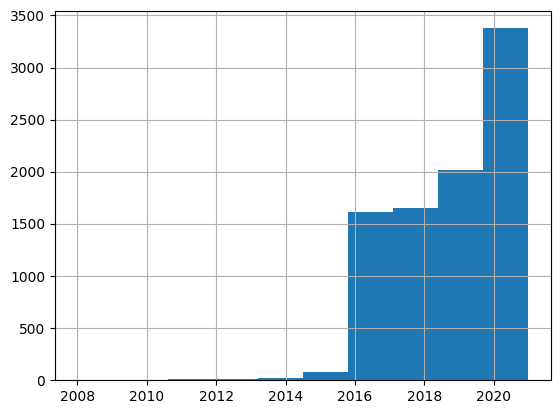

In [75]:
data.get_column("publication_year").to_pandas().hist()

<Axes: >

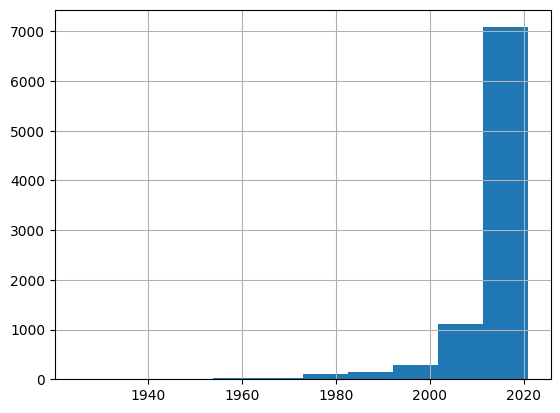

In [76]:
data.get_column("release_year").to_pandas().hist()

Годы выпуска и публикации отмасштабируем с помощью MinMaxScaler

In [77]:
from sklearn.preprocessing import MinMaxScaler

publication_scaler = MinMaxScaler()
release_scaler = MinMaxScaler()

release_scaled = release_scaler.fit_transform(
    data.get_column("release_year").to_numpy().reshape(-1, 1)
)

publication_scaled = publication_scaler.fit_transform(
    data.get_column("publication_year").to_numpy().reshape(-1, 1)
)

data = data.with_columns(
    release_year=pl.Series("release_year", release_scaled).list.explode(),
    publication_year=pl.Series("publication_year", publication_scaled).list.explode(),
)
data

show_id,type,title,release_year,publication_year,country_Argentina,country_Australia,country_Austria,country_Bangladesh,country_Belarus,country_Belgium,country_Brazil,country_Bulgaria,country_Cambodia,country_Cameroon,country_Canada,country_Chile,country_China,country_Colombia,country_Croatia,country_Cyprus,country_Czech Republic,country_Denmark,country_Egypt,country_Finland,country_France,country_Georgia,country_Germany,country_Ghana,country_Greece,country_Guatemala,country_Hong Kong,country_Hungary,country_Iceland,country_India,country_Indonesia,country_Iran,…,rating_UR,genre_Action & Adventure,genre_Anime Features,genre_Anime Series,genre_British TV Shows,genre_Children & Family Movies,genre_Classic & Cult TV,genre_Classic Movies,genre_Comedies,genre_Crime TV Shows,genre_Cult Movies,genre_Documentaries,genre_Docuseries,genre_Dramas,genre_Horror Movies,genre_Independent Movies,genre_International Movies,genre_International TV Shows,genre_Kids' TV,genre_LGBTQ Movies,genre_Movies,genre_Music & Musicals,genre_Reality TV,genre_Romantic Movies,genre_Romantic TV Shows,genre_Sci-Fi & Fantasy,genre_Spanish-Language TV Shows,genre_Sports Movies,genre_Stand-Up Comedy,genre_Stand-Up Comedy & Talk Shows,genre_TV Action & Adventure,genre_TV Comedies,genre_TV Dramas,genre_TV Horror,genre_TV Sci-Fi & Fantasy,genre_TV Shows,genre_Thrillers
str,i64,str,f64,f64,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,…,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8
"""s1""",0,"""Dick Johnson Is Dead""",0.989583,1.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""s2""",1,"""Blood & Water""",1.0,1.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""s3""",1,"""Ganglands""",1.0,1.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""s4""",1,"""Jailbirds New Orleans""",1.0,1.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""s5""",1,"""Kota Factory""",1.0,1.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""s8803""",0,"""Zodiac""",0.854167,0.846154,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""s8804""",1,"""Zombie Dumb""",0.96875,0.846154,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""s8805""",0,"""Zombieland""",0.875,0.846154,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


<Axes: >

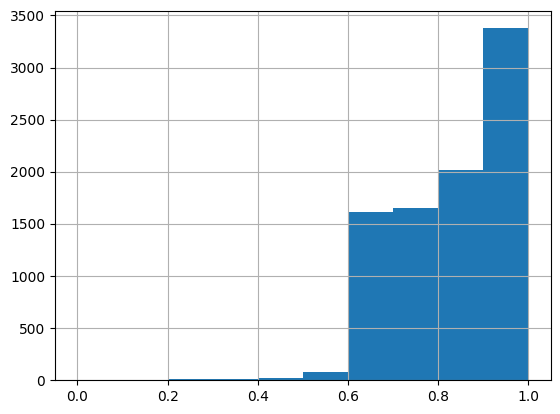

In [78]:
data.get_column("publication_year").to_pandas().hist()

<Axes: >

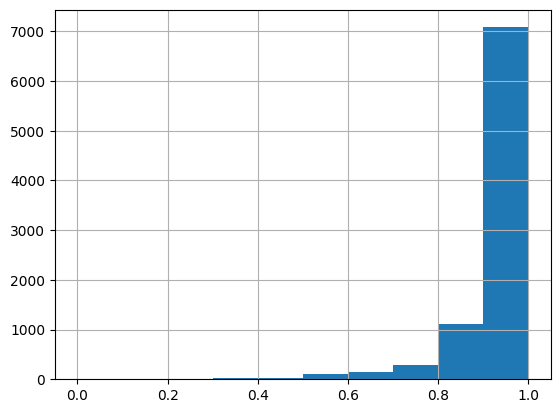

In [79]:
data.get_column("release_year").to_pandas().hist()